In [24]:
from sklearn.exceptions import DataConversionWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

# Input:

## import

In [25]:
from sklearn.exceptions import DataConversionWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [26]:
import torch
import torch.nn as nn
from torch.distributions import Categorical
import numpy as np
import gym

## Data Preparation:

In [27]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/aapl_Training_Data.csv")
data = data.set_index("Date")

training_data = data.loc[:, ~data.columns.isin(["target", "strength target", "regression target"])].copy()
target= data.loc[:, ["target"]].copy()

data.head()
display(training_data.shape, target.shape)

(2229, 93)

(2229, 1)

['volatility_bbhi', 'volatility_bbli', 'volatility_kchi', 'volatility_kcli', 'trend_psar_up_indicator', 'trend_psar_down_indicator']


Text(0, 0.5, 'Price')

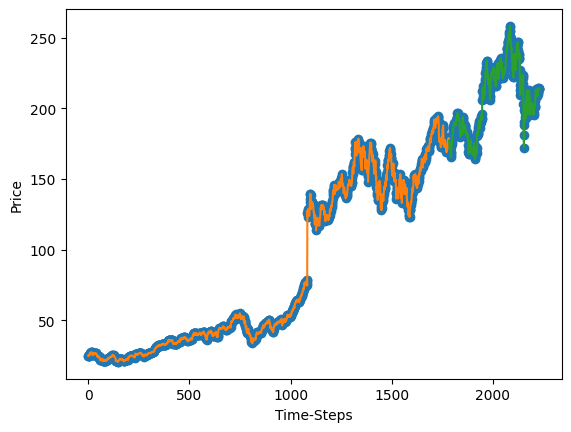

In [28]:
def data_split(split_percentage, df):

    assert 0 < split_percentage < 1, "split_percentage must be a float between 0 and 1 (exclusive)"
    
    split_index = int(len(df) * split_percentage)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()
    
    return train_df, test_df

def define_rule_based_indicators_list(X):
    rule_based_indicators =[]
    for col in X.columns:
        if len(X[col].unique()) <= 2:
            rule_based_indicators.append(col)
    
    return rule_based_indicators

print(define_rule_based_indicators_list(training_data))

#X, Valid_set, y, Valid_result = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
X, Valid_set = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
y, Valid_result = target.reset_index(drop=True).loc[X.index], target.reset_index(drop=True).loc[Valid_set.index]
from matplotlib import pyplot as plt

df = training_data.reset_index(drop=True)
price = df.loc[:, 'close']
plt.plot(price.index, price.values, 'o')

for df in [X, Valid_set]:
    price = df.loc[:, 'close']
    plt.plot(price.index, price.values)
    
plt.xlabel("Time-Steps")
plt.ylabel("Price")

# M1 layers processing:

## Fold CV fucntion:

In [29]:
def purged_kfold_split(X, n_splits=5, lookahead=5, embargo=0):
    fold_size = len(X) // n_splits
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Embargo
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        # Purge overlaps
        train_idx = list(range(0, test_start - lookahead)) + list(range(embargo_end, len(X)))
        test_idx = list(range(test_start, test_end))

        yield train_idx, test_idx

## Adding models:

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib

model_paths = ["knn_model_with_threshold.pkl", "logr_model_with_threshold.pkl", "rf_model_with_threshold.pkl", "xgb_model_with_threshold.pkl"]
model_names = ["KNNs", "LogR", "RF", "XGB"]
model_infor = {}

for name, path in zip(model_names, model_paths):
    model_infor[name] = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/{path}")

In [31]:
for key, infor in model_infor.items():
    print(f"{key}: {infor["model"]}")

KNNs: KNeighborsClassifier(algorithm='brute', leaf_size=71, n_jobs=-1, n_neighbors=29,
                     p=1)
LogR: LogisticRegression(C=0.26701973434500526, l1_ratio=0.4617895914797829,
                   max_iter=1000, penalty='elasticnet', random_state=42,
                   solver='saga')
RF: RandomForestClassifier(class_weight='balanced', max_depth=19,
                       max_features=0.17056866714444247, min_samples_split=3,
                       n_estimators=107, n_jobs=-1, random_state=42)
XGB: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.0537927537850279, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=9.492813163232885, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3949954489143

## M1-models Processing:

In [ ]:
from sklearn.metrics import f1_score

sub_training_data = X.copy()
sub_testing_data = Valid_set.copy()

for name, infor in model_infor.items():
    model = infor["model"]
    
    # record in the train-set
    X_train_1 = X.loc[:, infor["feature set"]].copy()
    model.fit(X_train_1, y)
    
    y_proba = model.predict_proba(X_train_1)[:, 1]
    sub_training_data[f"{name}_proba"] = y_proba
    
    y_pred = (y_proba > infor["threshold"]).astype(int)
    sub_training_data[f"{name}_prediction"] = y_pred
    #sub_training_data[f"{name}_valid"] = ( y_pred == y.to_numpy().T[0] ).astype(int)
    
    # record in the test-set
    X_test_1 = Valid_set.loc[:, infor["feature set"]].copy()
    
    y_proba = model.predict_proba(X_test_1)[:, 1]
    sub_testing_data[f"{name}_proba"] = y_proba
    
    y_pred = (y_proba > infor["threshold"]).astype(int)
    sub_testing_data[f"{name}_prediction"] = y_pred
    
    print( f"{name}_f1_score: {f1_score(y_true=Valid_result, y_pred=y_pred)}" )

In [33]:
display(sub_training_data.head())
display(sub_testing_data.head())

,close,high,low,open,volume,return,log_return,volume_adi,volume_obv,volume_cmf,...,others_dlr,others_cr,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction,XGB_proba,XGB_prediction
0,25.150589,25.299075,24.900860,24.932357,132197200,0.042753,0.001701,6.114034e+08,-537940800.0,0.175306,...,0.837678,-8.388360,0.551724,1,0.506618,1,0.217292,0,0.535508,1
1,24.795116,25.089841,24.648879,25.038096,177849600,-0.355473,-0.014235,6.450132e+08,-405743600.0,0.133383,...,0.111743,-8.232365,0.586207,1,0.525507,1,0.783902,1,0.535508,1
2,25.166340,25.220335,24.858116,24.957108,150694000,0.371223,0.014861,5.851254e+08,-583593200.0,0.215077,...,-2.162207,-9.529388,0.482759,1,0.522330,1,0.255255,0,0.535508,1
3,24.981848,25.197829,24.867107,25.148333,156930400,-0.184492,-0.007358,6.908925e+08,-432899200.0,0.188377,...,-0.413411,-8.174895,0.586207,1,0.536811,1,0.822645,1,0.535508,1
4,25.137081,25.141580,24.772612,24.927849,119036800,0.155233,0.006195,6.428529e+08,-589829600.0,0.180302,...,1.539425,-8.848056,0.482759,1,0.528012,1,0.856442,1,0.535508,1


,close,high,low,open,volume,return,log_return,volume_adi,volume_obv,volume_cmf,...,others_dlr,others_cr,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction,XGB_proba,XGB_prediction
1783,177.187302,177.544215,174.996248,175.234195,52517000,-0.128891,-0.000727,9.852421e+09,4.797363e+09,0.048591,...,1.677215,546.978391,0.482759,1,0.574613,1,0.497500,1,0.535508,1
1784,175.630753,176.889865,173.300915,175.135041,57549400,-1.556549,-0.008824,9.890225e+09,4.744846e+09,0.037707,...,0.616168,546.508103,0.586207,1,0.553723,1,0.536047,1,0.535508,1
1785,174.331985,176.057069,173.608250,174.074221,54764400,-1.298767,-0.007422,9.907394e+09,4.687296e+09,0.069149,...,-2.019475,540.828680,0.517241,1,0.567596,1,0.492008,1,0.535508,1
1786,173.955246,176.314825,173.687557,174.530259,59302900,-0.376740,-0.002163,9.885000e+09,4.632532e+09,0.080910,...,-0.892920,536.089834,0.620690,1,0.558661,1,0.458082,1,0.535508,1
1787,171.397400,173.915610,171.159453,173.806553,64244000,-2.557846,-0.014813,9.837782e+09,4.573229e+09,0.057929,...,0.493237,534.715214,0.482759,1,0.548511,1,0.449229,1,0.535508,1


## dataframe set-up with the m1 layers:

In [34]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import cross_val_score

def voting_method(data):
    score_array = []
    X_meta = []
    for name, infor in model_infor.items():
        
        '''
        y_pred= sub_training_data[f"{name}_prediction"]
        score = f1_score(y_pred=y_pred, y_true= y) 
        '''
        
        cv = purged_kfold_split(X.copy())
        score = cross_val_score(estimator=infor["model"], X=X.loc[:, infor["feature set"]].copy(), y=y.copy(), cv=cv, scoring="f1", n_jobs=-1).mean()
        score_array.append( score )
        
        X_meta.append(data[f"{name}_prediction"].tolist())
        print(f"{name}: {score_array[-1]}")

    # Weighted predictions (element-wise multiplication)
    score_array = np.array(score_array)
    #normalized_weights = score_array / score_array.sum()
    normalized_weights = score_array

    X_weighted = np.array(X_meta) * normalized_weights.reshape(4,1)
    
    # Same preds array as above
    weighted_votes = np.dot(X_weighted.T, normalized_weights)  # shape: (n_samples,)
    threshold = normalized_weights.sum() / 2
    final_preds = (weighted_votes >= threshold).astype(int)
    
    return final_preds

signals = []
record_1 = []
record_2 = []

def clustering_signal(data: pd.DataFrame, y_true: pd.Series): # just keep signal {1} or {0} for the input of the M2-layer
    final_preds = voting_method(data)
    returns = data['return'].values

    print()
    f1 = f1_score(y_pred=final_preds, y_true=y_true)
    total_return = returns[np.where(returns > 0)].sum()
    print(f"F1-Score: {f1}, Total Return: {total_return}")

    model_return = 0
    for i in range(len(final_preds)-1):
        if final_preds[i] == 1: ## only consider long trades with TP(+return) and FP(-return)
            #model_return += abs(returns[i]) if final_preds[i] == y.to_numpy().T[0][i] else -abs(returns[i])
            
            model_return += returns[i+1]
            
            signals.append( (y_true.to_numpy().T[0][i], returns[i+1]) )
            
            record_1.append( abs(returns[i+1]) if final_preds[i] == y_true.to_numpy().T[0][i] else -abs(returns[i+1]))
            record_2.append(returns[i+1])
            
    print(f"Model Return: {model_return}")
    print(np.unique(final_preds, return_counts=True))
    data = data.iloc[np.where(final_preds == 1)]
    
    return data

## M1-models Validation:

In [35]:
signals = []
record_1 = []
record_2 = []
clustering_signal(sub_training_data.copy(), y_true= y)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.5625471004258722


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A c

LogR: 0.6376899727599648


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea

RF: 0.5890133660637644
XGB: 0.6757316187535496

F1-Score: 0.9946977730646872, Total Return: 1034.8255519866943
Model Return: 1020.6149349212646
(array([0, 1]), array([843, 940]))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:01:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:01:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:01:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:01:08] WARN

,close,high,low,open,volume,return,log_return,volume_adi,volume_obv,volume_cmf,...,others_dlr,others_cr,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction,XGB_proba,XGB_prediction
1,24.795116,25.089841,24.648879,25.038096,177849600,-0.355473,-0.014235,6.450132e+08,-4.057436e+08,0.133383,...,0.111743,-8.232365,0.586207,1,0.525507,1,0.783902,1,0.535508,1
3,24.981848,25.197829,24.867107,25.148333,156930400,-0.184492,-0.007358,6.908925e+08,-4.328992e+08,0.188377,...,-0.413411,-8.174895,0.586207,1,0.536811,1,0.822645,1,0.535508,1
4,25.137081,25.141580,24.772612,24.927849,119036800,0.155233,0.006195,6.428529e+08,-5.898296e+08,0.180302,...,1.539425,-8.848056,0.482759,1,0.528012,1,0.856442,1,0.535508,1
6,25.593790,26.003255,25.580290,25.647785,167180800,-0.002251,-0.000088,9.080826e+08,-2.749216e+08,0.158693,...,0.807990,-6.607033,0.655172,1,0.528302,1,0.848877,1,0.535508,1
7,25.985264,25.985264,25.670291,25.722037,166616400,0.391474,0.015180,7.515739e+08,-4.421024e+08,0.167722,...,0.593073,-6.615246,0.655172,1,0.522329,1,0.773027,1,0.535508,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1775,172.170685,172.715971,169.503752,169.622718,53020300,1.249207,0.007282,9.709612e+09,4.586988e+09,-0.082364,...,-3.644955,523.645824,0.689655,1,0.574374,1,0.805411,1,0.535508,1
1776,173.409988,173.945351,171.199102,172.299583,48527900,1.239304,0.007172,9.744632e+09,4.640008e+09,-0.127621,...,-2.968576,528.203837,0.551724,1,0.553022,1,0.874222,1,0.535508,1
1777,175.967834,176.463546,171.694785,172.309478,57266700,2.557846,0.014643,9.774239e+09,4.688536e+09,-0.056293,...,0.348579,532.725718,0.482759,1,0.565463,1,0.812363,1,0.535508,1
1779,176.860123,178.178718,176.423894,176.572616,43698000,-0.594849,-0.003358,9.860426e+09,4.788194e+09,-0.027772,...,-1.720776,547.484756,0.586207,1,0.579383,1,0.781597,1,0.535508,1


In [36]:
print(signals)
print(record_1)
print(record_2)

[(1.0, 0.3712234497070312), (1.0, 0.1552333831787109), (1.0, 0.4589595794677734), (1.0, 0.3914737701416015), (1.0, 0.8054218292236328), (1.0, 1.061908721923828), (1.0, 0.2834663391113281), (1.0, 0.3779716491699219), (1.0, 0.3127212524414062), (1.0, 0.0316295623779296), (1.0, 0.4157371520996094), (1.0, 0.8133945465087891), (1.0, 0.3366546630859375), (1.0, 0.1174964904785156), (1.0, 0.2553138732910156), (1.0, 0.1107215881347656), (1.0, 0.8653678894042969), (1.0, 0.1242733001708984), (1.0, 0.1920585632324218), (1.0, 0.2937259674072265), (1.0, 0.3118057250976562), (1.0, 0.4338150024414062), (1.0, 0.0203323364257812), (1.0, 0.1152286529541015), (1.0, 0.3547325134277344), (1.0, 0.3231029510498047), (1.0, 0.4812602996826172), (1.0, 0.0293750762939453), (1.0, 1.1568336486816406), (1.0, 0.1242637634277343), (1.0, 0.1513786315917968), (1.0, 0.7343196868896484), (1.0, 0.4225082397460937), (1.0, 0.1749267578125), (1.0, 0.2248954772949218), (1.0, 0.0658798217773437), (1.0, 0.6019973754882812), (1.0

In [37]:
#df1["return"].iloc[np.where(df1["return"] > 0)].sum()

# LMST support functions:

In [38]:
import torch

#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")

device

device(type='cpu')

## Feature Selection:

In [39]:
selected_features = X.columns.copy()

## Train

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# LSTM Model Definition
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        if dropout == False:
            super(LSTMModel, self).__init__()
            self.lstm = nn.LSTM(input_size=input_size,
                                hidden_size=hidden_size,
                                num_layers=num_layers,
                                batch_first=True)
            self.relu = nn.ReLU()  # Add ReLU activation
            self.dropout = nn.Dropout(0.3)
            self.fc1 = nn.Linear(hidden_size, 32)
            self.fc2 = nn.Linear(32, 1)
        else:
            super(LSTMModel, self).__init__()
            self.lstm = nn.LSTM(input_size=input_size,
                                hidden_size=hidden_size,
                                num_layers=num_layers,
                                dropout=dropout if num_layers > 1 else 0,
                                batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)
            self.sigmoid = nn.Sigmoid()
            self.dropout = dropout

    def forward(self, x):
        if self.dropout == False:
            out, _ = self.lstm(x)
            out = out[:, -1, :]  # Get the last time step
            out = self.dropout(out)
            out = self.relu(self.fc1(out))
            out = self.fc2(out)
            return out
        else:
            out, _ = self.lstm(x)
            out = out[:, -1, :]  # Take last timestep
            out = self.fc(out)
            return self.sigmoid(out)

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

# Training Function
def LSTM__training(X_train, y_train, hidden_size=64, num_epochs=20, lr=1e-3, num_layers=1, dropout=False, batch_size=64, sequence_length=1):
    
    X_train, y_train = create_sequences(X_train, y_train, seq_len=sequence_length)
    
    # Convert to PyTorch tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    # Ensure X has 3D shape [batch, seq_len, features]
    if X_train.ndim == 2:
        X_train = X_train[:, None, :]  # add seq_len=1 dimension
    X_train, y_train = X_train.to(device), y_train.to(device)

    # Define model
    input_size = X_train.shape[2]
    model = LSTMModel(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout).to(device)
    
    '''
    # Compute class imbalance for BCEWithLogitsLoss
    num_pos = (y_train == 1).sum().item()
    num_neg = (y_train == 0).sum().item()

    if num_pos == 0:  # Avoid divide-by-zero
        pos_weight = torch.tensor(1.0, dtype=torch.float32).to(device)
    else:
        pos_weight = torch.tensor(num_neg / num_pos, dtype=torch.float32).to(device)

    # Define loss and optimizer
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    '''

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Training loop
    model.train()
    if dropout == False:
        for epoch in range(num_epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                outputs = model(xb).squeeze()
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()
    else:
        for epoch in range(100):  # Keep it short for BO
            for i in range(0, len(X_train), batch_size):
                xb = torch.tensor(X_train[i:i+batch_size]).to(device)
                yb = torch.tensor(y_train[i:i+batch_size]).view(-1, 1).to(device)
                optimizer.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                loss.backward()
                optimizer.step()
        '''
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")
        '''

    return model

## Hyperparameter Tuning:

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from bayes_opt import BayesianOptimization
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def hyperparams_tuning(X_train_1: pd.DataFrame, y_train_1: pd.Series):
    def train_model(hidden_size, num_layers, dropout, lr, batch_size, sequence_length):
        hidden_size = int(hidden_size)
        num_layers = int(num_layers)
        batch_size = int(batch_size)
        sequence_length = int(sequence_length)
        
        f1_array = np.array([])
        for train_idx, val_idx in purged_kfold_split(X_train_1.copy()):
            X_train, X_val = X_train_1.iloc[train_idx, :], X_train_1.iloc[val_idx, :]
            y_train, y_val = y_train_1.iloc[train_idx, :], y_train_1.iloc[val_idx, :]

            model = LSTM__training(X_train.to_numpy(), y_train.to_numpy(), hidden_size=hidden_size, lr=lr, num_layers=num_layers, dropout=dropout, batch_size=batch_size, sequence_length=sequence_length).to(device)
            
            X_val, y_val = create_sequences(X_val.to_numpy(), y_val.to_numpy(), seq_len=sequence_length)
            X_val, y_val = torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)
            
            # Ensure X has 3D shape [batch, seq_len, features]
            if X_val.ndim == 2:
                X_val = X_val[:, None, :]  # add seq_len=1 dimension
            X_val, y_val = X_val.to(device), y_val.to(device)

            # Evaluate
            model.eval()
            val_preds = []
            with torch.no_grad():
                for i in range(0, len(X_val), batch_size):
                    xb = torch.tensor(X_val[i:i+batch_size]).to(device)
                    preds = model(xb).detach().cpu().numpy().flatten()
                    val_preds.extend(preds)
                val_preds = (np.array(val_preds) > 0.5).astype(int)
                y_val_trimmed = y_val.detach().cpu().numpy().flatten()
                score = f1_score(y_val_trimmed, val_preds)
        
        f1_array = np.append(f1_array, score)
        
        return f1_array.mean()

    # Define the BO space
    pbounds = {
        'hidden_size': (32, 256),
        'num_layers': (1, 3),
        'dropout': (0.0, 0.5),
        'lr': (1e-4, 1e-2),
        'batch_size': (32, 128),
        'sequence_length': (10, 50)
    }

    # Run Bayesian Optimization
    optimizer = BayesianOptimization(
        f=train_model,
        pbounds=pbounds,
        verbose=2,
        random_state=42
    )

    optimizer.maximize(init_points=5, n_iter=15)

    print("\n🔍 Best Parameters:")
    print(optimizer.max)
    return optimizer.max['params']

## Threshold tuning

In [42]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve
import numpy as np

def Threshold_tuning(model, y_train_1, X_train_1, seq_len, batch_size):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_true_all = []
    y_proba_all = []

    for train_idx, val_idx in kf.split(X_train_1, y_train_1):
        X_train, X_val = X_train_1.iloc[train_idx, :], X_train_1.iloc[val_idx, :]
        y_train, y_val = y_train_1.iloc[train_idx, :], y_train_1.iloc[val_idx, :]
        
        ### test set for threshold identify:
        X_val, y_val = create_sequences(X_val.to_numpy(), y_val.to_numpy(), seq_len)
        X_val = torch.tensor(X_val, dtype=torch.float32)  # X_test must be a 3D array
        y_val = torch.tensor(y_val, dtype=torch.float32)
        if X_val.ndim == 2:
            X_val = X_val[:, None, :]  # add seq_len=1 dimension
        X_val = X_val.to(device)
        y_val = y_val.to(device)
        
        val_preds = []
        # Evaluate
        model.eval()
        val_preds = []
        with torch.no_grad():
            for i in range(0, len(X_val), batch_size):
                xb = torch.tensor(X_val[i:i+batch_size]).to(device)
                preds = model(xb).detach().cpu().numpy().flatten()
                val_preds.extend(preds)
                #val_preds = (np.array(val_preds) > 0.5).astype(int)
            
            y_val_trimmed = y_val.detach().cpu().numpy().flatten()
            

            # Store true and predicted values
            y_true_all.extend(y_val_trimmed)
            y_proba_all.extend(val_preds)

    # Convert to numpy arrays
    y_true_all = np.array(y_true_all)
    y_proba_all = np.array(y_proba_all)

    # Compute precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_true_all, y_proba_all)

    # Compute F1 scores for each threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

    # Get best threshold
    best_threshold = thresholds[np.argmax(f1_scores)]

    print(f"Best threshold from 5-fold CV: {best_threshold}")
    return best_threshold

# LSTM model ACTIVE:

## Data Preparation

In [43]:
'''
df1 = clustering_signal(sub_training_data.copy(), y_true= y)
df2 = clustering_signal(sub_testing_data.copy(), y_true= Valid_result)
'''

l = X.columns.tolist().copy()
#l.remove('return')

df1 = sub_training_data.loc[:, ~sub_training_data.columns.isin(l)]
df2 = sub_testing_data.loc[:, ~sub_testing_data.columns.isin(l)]
'''
X_train_1 = X.loc[:, selected_features].copy()
y_train_1 = y.copy()
X_test = Valid_set.loc[:, selected_features].copy().to_numpy()
y_test = Valid_result.copy().T.to_numpy()[0]
'''
X_train_1 = df1.copy()
y_train_1 = y.copy()
X_test_1 = df2.copy()
y_test_1 = Valid_result.copy()

## Params_Tuning:

In [44]:
best_params = hyperparams_tuning(X_train_1, y_train_1)

|   iter    |  target   | batch_... |  dropout  | hidden... |    lr     | num_la... | sequen... |
-------------------------------------------------------------------------------------------------
| 1         | 0.5722    | 67.96     | 0.4754    | 196.0     | 0.006027  | 1.312     | 16.24     |
| 2         | 0.6332    | 37.58     | 0.4331    | 166.6     | 0.00711   | 1.041     | 48.8      |
| 3         | 0.5989    | 111.9     | 0.1062    | 72.73     | 0.001916  | 1.608     | 30.99     |
| 4         | 0.5714    | 73.47     | 0.1456    | 169.1     | 0.001481  | 1.584     | 24.65     |
| 5         | 0.6414    | 75.78     | 0.3926    | 76.73     | 0.005191  | 2.185     | 11.86     |
| 6         | 0.5773    | 54.48     | 0.2606    | 70.55     | 0.003124  | 1.643     | 16.39     |
| 7         | 0.6851    | 38.06     | 0.2163    | 167.3     | 0.006322  | 2.038     | 47.52     |
| 8         | 0.5757    | 37.81     | 0.2028    | 165.6     | 0.001205  | 1.118     | 46.67     |


KeyboardInterrupt: 

## Defined through training fucntion:

In [ ]:
best_params['X_train'] = X_train_1.copy().to_numpy()
best_params['y_train'] = y_train_1.to_numpy().T[0]
'''
best_params['X_train'] = X.loc[:, selected_features].copy()
best_params['y_train'] = y.copy()
'''

for param in ["hidden_size", "num_layers", "batch_size", "sequence_length"]:
    best_params[param] = int(best_params[param])

In [ ]:
model = LSTM__training(**best_params)

## Threshold Tuning Result:

In [ ]:
'''
X_train_1 = X.loc[:, selected_features].copy().reset_index(drop=True)
y_train_1 = y.copy().reset_index(drop=True)
'''
best_threshold = Threshold_tuning(model=model, X_train_1=X_train_1, y_train_1=y_train_1, seq_len=best_params['sequence_length'], batch_size=best_params['batch_size'])

Best threshold from 5-fold CV: 0.3869541883468628


## Forcasting:

In [ ]:
'''
X_test = Valid_set.loc[:, selected_features].copy().to_numpy()
y_test = Valid_result.copy().T.to_numpy()[0]
'''
X_test, y_test = create_sequences(X_test_1, y_test_1.to_numpy().T[0], seq_len=best_params['sequence_length'])
# Convert to PyTorch tensors FIRST before sending to MPS
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
if X_test.ndim == 2:
    X_test = X_test[:, None, :]
# Now move tensors to   
X_test = X_test.to(device)
y_test = y_test.to(device)

# Evaluate
batch_size=best_params['batch_size']
model.eval()
val_preds = []
with torch.no_grad():
    for i in range(0, len(X_test), batch_size):
        xb = torch.tensor(X_test[i:i+batch_size]).to(device)
        preds = model(xb).detach().cpu().numpy().flatten()
        val_preds.extend(preds)
    y_val_trimmed = y_test.detach().cpu().numpy().flatten()

y_pred_prob = np.array(val_preds.copy())

# y_test back to CPU for metrics
y_true = y_val_trimmed
"""
"""
#best_threshold = (y_pred_prob.min() + y_pred_prob.max())/2
y_pred = (y_pred_prob >= best_threshold).astype(int)

print(f"The best Threshold: {best_threshold}")
print(f"F1-Score: {f1_score(y_true, y_pred)}")

The best Threshold: 0.3869541883468628
F1-Score: 0.7076461769115442


In [ ]:
f1_score(y_true, (y_pred_prob >= 0.5).astype(int))

0.4690721649484536

# Diagnosis:

### Proba Check:

[1]
0.3869542


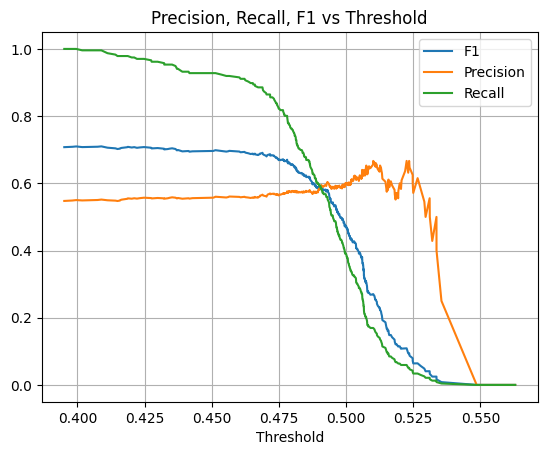

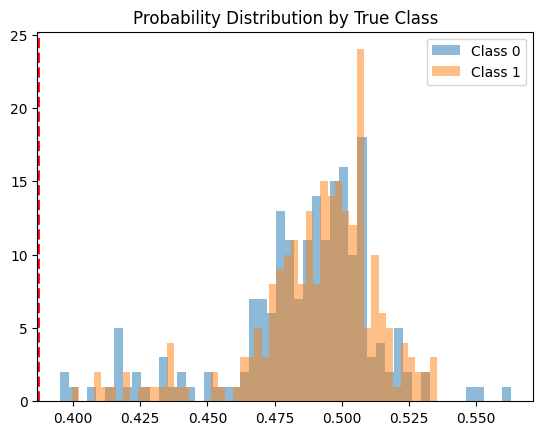

In [ ]:
from matplotlib import pyplot as plt

print(np.unique(y_pred))

precision, recall, thresholds = precision_recall_curve(y_true, y_pred_prob)
f1 = 2 * precision * recall / (precision + recall + 1e-6)
'''
best_threshold = thresholds[np.argmax(f1)]
best_threshold = thresholds[np.where(precision == recall)].min()
'''
print(best_threshold)
    
plt.plot(thresholds, f1[:-1], label='F1')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid()
plt.show()

plt.hist(y_pred_prob[y_true==0], bins=50, alpha=0.5, label='Class 0')
plt.hist(y_pred_prob[y_true==1], bins=50, alpha=0.5, label='Class 1')
plt.axvline(x= best_threshold, linestyle="--", linewidth=2, color="red")
plt.legend()
plt.title(f"Probability Distribution by True Class")
plt.show()

In [ ]:
print("Feature stats:")
display(X_train_1.describe())

Feature stats:


,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction,XGB_proba,XGB_prediction
count,1783.000000,1783.000000,1783.000000,1783.000000,1783.000000,1783.000000,1783.000000,1783.0
mean,0.530566,0.999439,0.529271,0.988222,0.527402,0.531688,0.533390,1.0
std,0.082300,0.023682,0.052831,0.107915,0.299513,0.499135,0.023470,0.0
min,0.275862,0.000000,0.163702,0.000000,0.045177,0.000000,0.503663,1.0
25%,0.482759,1.000000,0.499493,1.000000,0.218260,0.000000,0.503663,1.0
50%,0.517241,1.000000,0.531898,1.000000,0.707295,1.000000,0.535508,1.0
75%,0.586207,1.000000,0.563080,1.000000,0.811575,1.000000,0.535508,1.0
max,0.724138,1.000000,0.687574,1.000000,0.952813,1.000000,0.574866,1.0


## Validation:

In [ ]:
import numpy as np
print("Test labels:", np.unique(y, return_counts=True))
print("Test labels:", np.unique(y_true, return_counts=True))
print("Predictions:", np.unique(y_pred, return_counts=True))

Test labels: (array([0., 1.]), array([837, 946]))
Test labels: (array([0., 1.]), array([202, 244]))
Test labels: (array([0., 1.], dtype=float32), array([195, 236]))
Predictions: (array([0, 1]), array([115, 316]))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Confusion Matrix:
[[ 61 134]
 [ 54 182]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.53      0.31      0.39       195
         1.0       0.58      0.77      0.66       236

    accuracy                           0.56       431
   macro avg       0.55      0.54      0.53       431
weighted avg       0.56      0.56      0.54       431

